In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from manify.manifolds import ProductManifold
from manify.curvature_estimation.delta_hyperbolicity import delta_hyperbolicity, sampled_delta_hyperbolicity
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

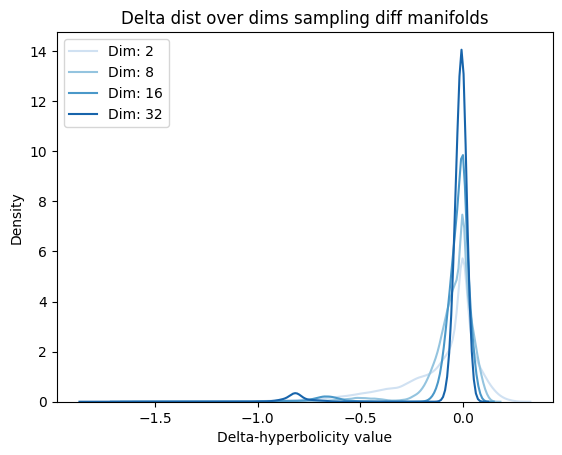

In [4]:
# Multiple Manifolds
CURVATURE = -1 
dims = [2,8,16,32]
N = 50

all_deltas = []

for dim in dims:
    pm = ProductManifold(signature=[(CURVATURE, dim)])
    X, _ = pm.sample(z_mean=torch.stack([pm.mu0] * N))
    dists = pm.pdist(X)
    curr_deltas = delta_hyperbolicity(dists)
    all_deltas.append(curr_deltas)

# Make seaborn kdeplots for each curvature
colors = sns.color_palette("Blues", len(dims))
for i, deltas in enumerate(all_deltas):
    sns.kdeplot(deltas.detach().cpu().numpy().flatten(), label=f"Dim: {dims[i]}", color=colors[i])
plt.xlabel("Delta-hyperbolicity value")
plt.ylabel("Density")
plt.title("Delta dist over dims sampling diff manifolds")
plt.legend()
plt.show()

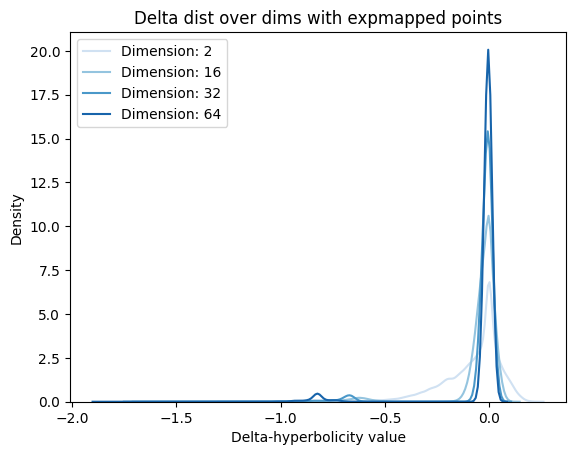

In [5]:
# Same point exp mapped 
N_SAMPLES = 50
CURVATURE = -1
dims = [2,16,32,64]

N = torch.distributions.MultivariateNormal(loc=torch.zeros(max(dims)), covariance_matrix=torch.eye(max(dims)))

# Get a single sample
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

all_deltas = []
for dim in dims:
    pm = ProductManifold(signature=[(CURVATURE, dim)])

    # Get the distance
    dists = pm.pdist(pm.expmap(x_tangent[:, : dim + 1]))
    deltas = delta_hyperbolicity(dists)

    all_deltas.append(deltas)

# KDE plot
colors = sns.color_palette("Blues", len(dims))
for i, deltas in enumerate(all_deltas):
    sns.kdeplot(deltas.detach().cpu().numpy().flatten(), label=f"Dimension: {dims[i]}", color=colors[i])
plt.xlabel("Delta-hyperbolicity value")
plt.ylabel("Density")
plt.title("Delta dist over dims with expmapped points")
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


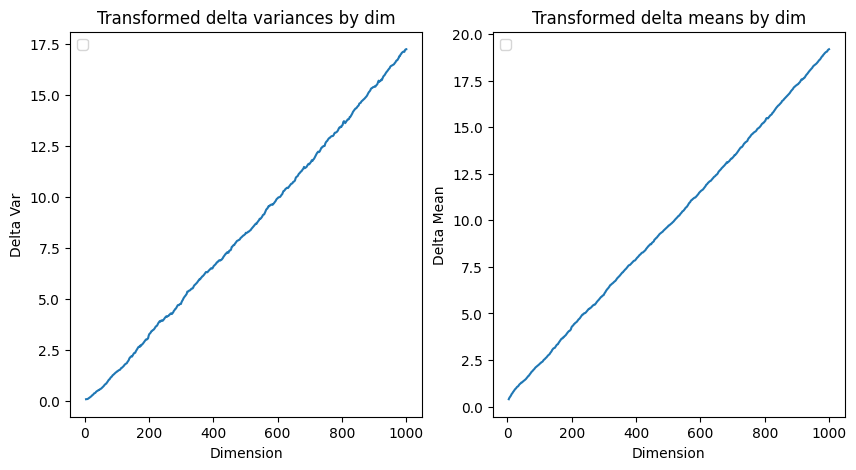

In [10]:
# Mean and variance of delta dist as a function of dimensionality 

dims = np.linspace(4,1000,500, dtype=int).tolist()
CURVATURE = -1
N_SAMPLES = 100

N = torch.distributions.MultivariateNormal(loc=torch.zeros(max(dims)), covariance_matrix=torch.eye(max(dims)))

# Get a single sample
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

delta_means = []
delta_vars = []


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for dim in dims:
    MEAN_TRANSFORM = dim
    STD_TRANSFORM = dim
    pm = ProductManifold(signature=[(CURVATURE,dim)])
    dists = pm.pdist(pm.expmap(x_tangent[:, :dim+1]))
    deltas = delta_hyperbolicity(dists)
    delta_means.append(torch.abs(deltas).mean().item() * MEAN_TRANSFORM)
    delta_vars.append(deltas.std().item()**2 * STD_TRANSFORM)

# Fit a regressor:
from sklearn.linear_model import LinearRegression


dim_reg = LinearRegression().fit(np.array(dims).reshape(-1,1), np.array(delta_means))

axes[0].plot(dims, delta_vars)
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Delta Var')
axes[0].set_title("Transformed delta variances by dim")
axes[0].legend()

axes[1].plot(dims, delta_means)
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Delta Mean')
axes[1].set_title("Transformed delta means by dim")
axes[1].legend()

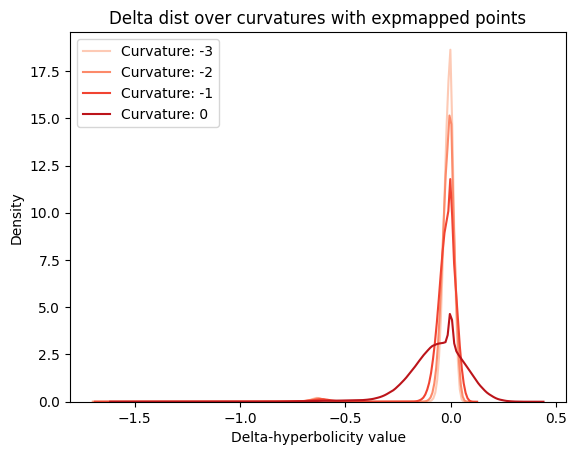

In [7]:
# Same point exp mapped 
N_SAMPLES = 100
DIM = 16
Ks = [-3,-2,-1,0]

N = torch.distributions.MultivariateNormal(loc=torch.zeros(DIM), covariance_matrix=torch.eye(DIM))

# Get a single sample
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

all_deltas = []
for k in Ks:
    pm = ProductManifold(signature=[(k, DIM)])

    # Get the distance
    dists = pm.pdist(pm.expmap(x_tangent))
    deltas = delta_hyperbolicity(dists)

    all_deltas.append(deltas)

# KDE plot
colors = sns.color_palette("Reds", len(Ks))
for i, deltas in enumerate(all_deltas):
    sns.kdeplot(deltas.detach().cpu().numpy().flatten(), label=f"Curvature: {Ks[i]}", color=colors[i])
plt.xlabel("Delta-hyperbolicity value")
plt.ylabel("Density")
plt.title("Delta dist over curvatures with expmapped points")
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


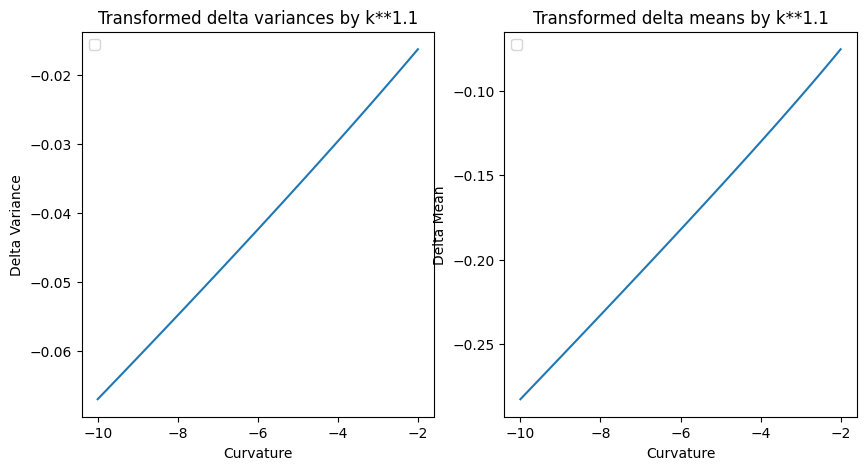

In [12]:
# Mean and variance of delta dist as a function of curvature
import math
Ks = np.linspace(-10,-2,100).tolist()
DIM = 16
N_SAMPLES = 100

N = torch.distributions.MultivariateNormal(loc=torch.zeros(DIM), covariance_matrix=torch.eye(DIM))

# Get a single sample
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

delta_means = []
delta_vars = []

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for k in Ks:
    MEAN_TRANSFORM = k**1.1
    STD_TRANSFORM = k**.9

    pm = ProductManifold(signature=[(k,DIM)])
    dists = pm.pdist(pm.expmap(x_tangent))
    deltas = delta_hyperbolicity(dists)
    delta_means.append(torch.abs(deltas).mean().item() * MEAN_TRANSFORM)
    delta_vars.append(deltas.std().item()**2 * STD_TRANSFORM)

axes[0].plot(Ks, delta_vars)
axes[0].set_xlabel('Curvature')
axes[0].set_ylabel('Delta Variance')
axes[0].set_title("Transformed delta variances by k**1.1")
axes[0].legend()

axes[1].plot(Ks, delta_means)
axes[1].set_xlabel('Curvature')
axes[1].set_ylabel('Delta Mean')
axes[1].set_title("Transformed delta means by k**1.1")
axes[1].legend()

In [71]:
import itertools


N_SAMPLES = 1000
N_MANIFOLD_SAMPLES = 100
# dims = np.linspace(2,100,N_SAMPLES, dtype=int).tolist()
# Ks = np.linspace(-3,-1,N_SAMPLES).tolist()

dims = np.random.randint(2,100,N_SAMPLES)
Ks = np.random.uniform(-5, -1, N_SAMPLES)
data = np.column_stack((dims, Ks))

N = torch.distributions.MultivariateNormal(loc=torch.zeros(max(dims)), covariance_matrix=torch.eye(max(dims)))

# Get a single sample
x = N.sample(sample_shape=(N_MANIFOLD_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_MANIFOLD_SAMPLES, 1), x])

delta_means = np.zeros((N_SAMPLES,))

for ix in range(N_SAMPLES):
    dim, k = data[ix]
    MEAN_TRANSFORM = dim * k
    pm = ProductManifold(signature=[(k, int(dim))])
    dists = pm.pdist(pm.expmap(x_tangent[:, : int(dim) + 1]))
    deltas = delta_hyperbolicity(dists)
    delta_means[ix] = torch.abs(deltas).mean().item()

In [72]:
additive_reg = LinearRegression().fit(data.reshape(-1,2), delta_means) # Give both dim and k
multiplicative_reg = LinearRegression().fit((data[:,0] * data[:,1]).reshape(-1,1), delta_means) # Only give k * dim

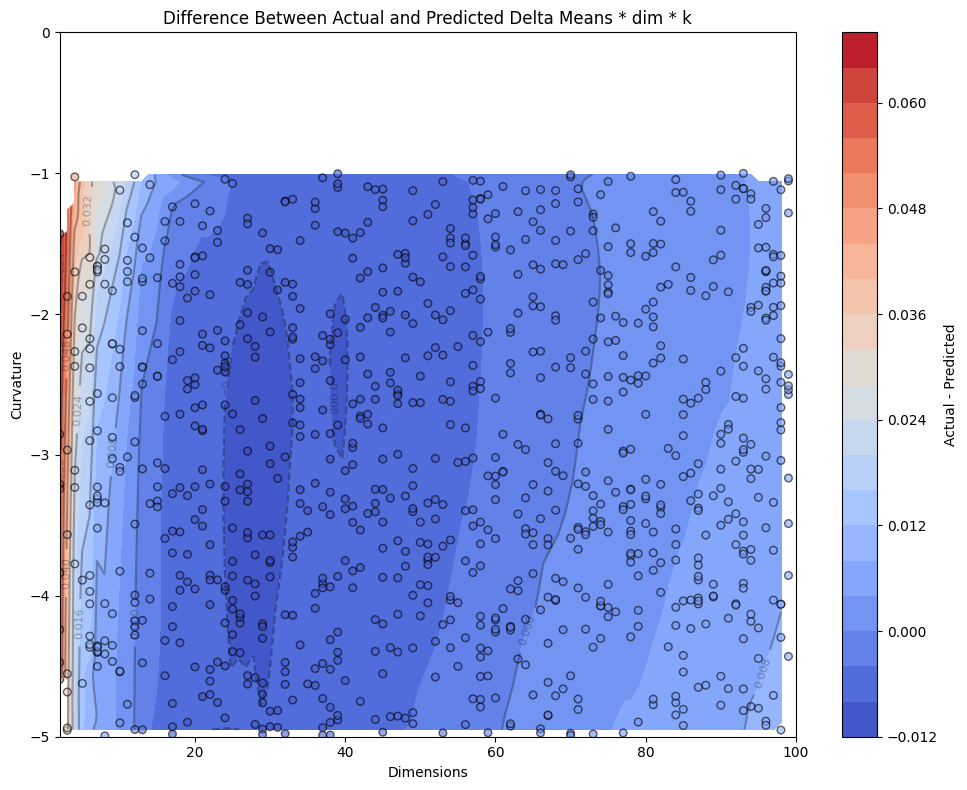

In [ ]:
# mu = (a / k) +( b / d) + (c / dk
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import griddata

reg = additive_reg

# Calculate predicted values
predicted_means = reg.predict(data)
differences = (delta_means - predicted_means)

# Define grid for contour plot
dim_grid = np.linspace(2, 100, 100)
k_grid = np.linspace(-5, 0, 100)
X, Y = np.meshgrid(dim_grid, k_grid)

# Interpolate differences onto the grid
Z = griddata((data[:, 0], data[:, 1]), differences, (X, Y), method='cubic')

# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, Z, 20, cmap=cm.coolwarm)
plt.colorbar(contour, label='Actual - Predicted')
plt.xlabel('Dimensions')
plt.ylabel('Curvature')
plt.title('Difference Between Actual and Predicted Delta Means * dim * k')

# Add scatter points for the original data
scatter = plt.scatter(data[:, 0], data[:, 1], c=differences, cmap=cm.coolwarm, 
                     s=30, edgecolor='k', alpha=0.6)

# Add contour lines
contour_lines = plt.contour(X, Y, Z, 10, colors='black', alpha=0.3)
plt.clabel(contour_lines, inline=True, fontsize=8)

plt.tight_layout()
plt.show()

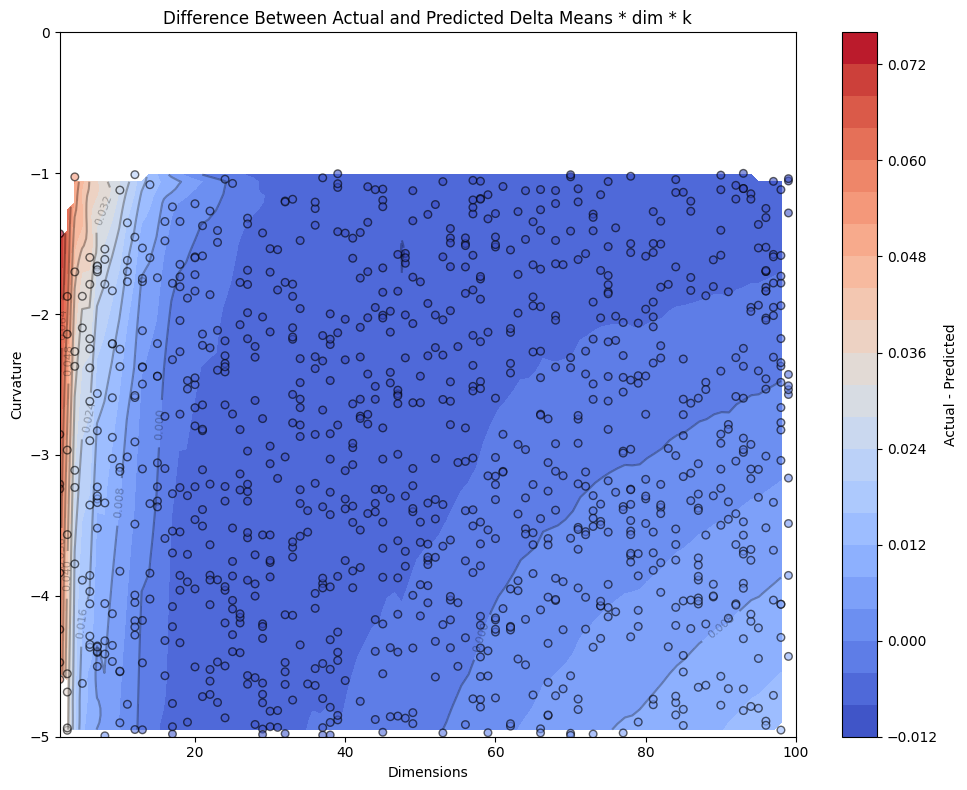

In [80]:
# mu = a + b / (k * dim)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import griddata

reg = multiplicative_reg

# Calculate predicted values
data_multiplied = (data[:,0] * data[:,1]).reshape(-1,1  )
predicted_means = reg.predict(data_multiplied)
differences = (delta_means - predicted_means)

# Define grid for contour plot
dim_grid = np.linspace(2, 100, 100)
k_grid = np.linspace(-5, 0, 100)
X, Y = np.meshgrid(dim_grid, k_grid)

# Interpolate differences onto the grid
Z = griddata((data[:, 0], data[:, 1]), differences, (X, Y), method='cubic')

# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, Z, 20, cmap=cm.coolwarm)
plt.colorbar(contour, label='Actual - Predicted')
plt.xlabel('Dimensions')
plt.ylabel('Curvature')
plt.title('Difference Between Actual and Predicted Delta Means * dim * k')

# Add scatter points for the original data
scatter = plt.scatter(data[:, 0], data[:, 1], c=differences, cmap=cm.coolwarm, 
                     s=30, edgecolor='k', alpha=0.6)

# Add contour lines
contour_lines = plt.contour(X, Y, Z, 10, colors='black', alpha=0.3)
plt.clabel(contour_lines, inline=True, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print(f'mu = {reg.intercept_} / (kd) + {reg.coef_[0]}')

mu = 0.03805412050093507 / (kd) + 6.46790860759585e-05
